<a href="https://colab.research.google.com/github/GuiOlympio/Classificacao_mri_alzheimer_cnn/blob/SemComprometimento_ComprometimentoLeve/IcGuilherme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("lukechugh/best-alzheimer-mri-dataset-99-accuracy")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'best-alzheimer-mri-dataset-99-accuracy' dataset.
Path to dataset files: /kaggle/input/best-alzheimer-mri-dataset-99-accuracy


In [2]:
import os

#obtem o nome do caminho das base de teste e treino
print("Conteúdo da pasta do dataset:")
print(os.listdir(path))

Conteúdo da pasta do dataset:
['Combined Dataset']


In [3]:
dataset_dir = os.path.join(path, "Combined Dataset")

print("Conteúdo da pasta Combined Dataset:")
print(os.listdir(dataset_dir))

Conteúdo da pasta Combined Dataset:
['test', 'train']


In [4]:
train = os.path.join(dataset_dir, "train")

print("Conteúdo da pasta train:")
print(os.listdir(train))

Conteúdo da pasta train:
['No Impairment', 'Very Mild Impairment', 'Moderate Impairment', 'Mild Impairment']


In [5]:
import pathlib
caminho = pathlib.Path(train)

categorias = [d.name for d in caminho.iterdir() if d.is_dir()]

for categoria in categorias:
  print(f" - {categoria}")

 - No Impairment
 - Very Mild Impairment
 - Moderate Impairment
 - Mild Impairment


In [6]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pathlib, os, shutil
import hashlib


caminho = pathlib.Path(train)
diretorio_subconjunto = pathlib.Path("subconjunto de Alzheimer")

if diretorio_subconjunto.exists():
    shutil.rmtree(diretorio_subconjunto)

categorias = ['No Impairment', 'Mild Impairment']

def redimensiona_com_padding(caminho_img, tamanho_alvo=(224, 224)):

    """
     Redimensiona a imagem mantendo a proporção original do cérebro
     e preenche as bordas com fundo preto (0,0,0) até atingir 224x224.
    """
    img = cv2.imread(str(caminho_img))
    if img is None:
        return None

    h, w, _ = img.shape
    alvo_h, alvo_w = tamanho_alvo

    # Mantém a escala exata da anatomia
    escala = min(alvo_w / w, alvo_h / h)
    novo_w, novo_h = int(w * escala), int(h * escala)

    img_redim = cv2.resize(img, (novo_w, novo_h), interpolation=cv2.INTER_AREA)

    # Tela preta de fundo
    img_pad = np.zeros((alvo_h, alvo_w, 3), dtype=np.uint8)

    # Centraliza a ressonância
    top = (alvo_h - novo_h) // 2
    left = (alvo_w - novo_w) // 2
    img_pad[top:top+novo_h, left:left+novo_w] = img_redim

    return cv2.cvtColor(img_pad, cv2.COLOR_BGR2RGB)

# Pega 10 amostras do dataset limpo para exibição
amostras = list((diretorio_subconjunto / "treino" / "No Impairment").glob("*"))[:10]

plt.figure(figsize=(15, 6))
for idx, img_path in enumerate(amostras):
    img_padded = redimensiona_com_padding(img_path)
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img_padded)
    plt.title(f"Amostra {idx + 1}\n224x224 (Padded)", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


<Figure size 1500x600 with 0 Axes>

In [7]:
def processa_e_filtra_categorias():
    dados_filtrados = {}

    print("=== RELATÓRIO DE FILTRAGEM DE IMAGENS ===")
    for categoria in categorias:
        categoria_diretorio = caminho / categoria

        hashes_vistos = set()
        fnomes_validos = []

        qtd_total = 0
        qtd_ruido = 0
        qtd_duplicadas = 0

        arquivos = os.listdir(categoria_diretorio)
        qtd_total = len(arquivos)

        for fnome in arquivos:
            img_path = categoria_diretorio / fnome

            # 1. Filtro de ruído / imagens vazias ou corrompidas
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None or np.var(img) < 100.0:
                qtd_ruido += 1
                continue

            # 2. Filtro de duplicatas (MD5 Hash)
            with open(img_path, "rb") as f:
                h = hashlib.md5(f.read()).hexdigest()

            if h in hashes_vistos:
                qtd_duplicadas += 1
                continue

            hashes_vistos.add(h)
            fnomes_validos.append(fnome)

        dados_filtrados[categoria] = fnomes_validos

        print(f"\nCategoria: [{categoria}]")
        print(f" - Total de arquivos analisados : {qtd_total}")
        print(f" - Imagens com ruído/invalidas   : {qtd_ruido}")
        print(f" - Imagens duplicadas           : {qtd_duplicadas}")
        print(f" - Imagens válidas mantidas     : {len(fnomes_validos)}")

    return dados_filtrados

# 1. Executa a filtragem e exibe o relatório
arquivos_validos_por_categoria = processa_e_filtra_categorias()

# 2. Função para copiar as imagens válidas já filtradas
def copia_subconjunto(subconjunto_nome, inicia_index, finaliza_index):
    for categoria, fnomes_validos in arquivos_validos_por_categoria.items():
        diretorio_destino = diretorio_subconjunto / subconjunto_nome / categoria
        os.makedirs(diretorio_destino, exist_ok=True)

        fnomes = fnomes_validos[inicia_index:finaliza_index]

        for fnome in fnomes:
            caminho_origem = caminho / categoria / fnome

            # LER E APLICAR O PADDING ANTES DE SALVAR
            img_padded_rgb = redimensiona_com_padding(caminho_origem, tamanho_alvo=(224, 224))
            if img_padded_rgb is not None:
                # Converter de RGB de volta para BGR para salvar com OpenCV
                img_bgr = cv2.cvtColor(img_padded_rgb, cv2.COLOR_RGB2BGR)
                cv2.imwrite(str(diretorio_destino / fnome), img_bgr)

# 3. Cria as divisões
copia_subconjunto("treino", inicia_index=0, finaliza_index=1000)
copia_subconjunto("validacao", inicia_index=1000, finaliza_index=1500)
copia_subconjunto("teste", inicia_index=1500, finaliza_index=2000)

=== RELATÓRIO DE FILTRAGEM DE IMAGENS ===

Categoria: [No Impairment]
 - Total de arquivos analisados : 2560
 - Imagens com ruído/invalidas   : 0
 - Imagens duplicadas           : 0
 - Imagens válidas mantidas     : 2560

Categoria: [Mild Impairment]
 - Total de arquivos analisados : 2560
 - Imagens com ruído/invalidas   : 0
 - Imagens duplicadas           : 125
 - Imagens válidas mantidas     : 2435


In [8]:
import PIL

In [9]:
for subpasta in categorias:
  caminho_subpasta = diretorio_subconjunto/ "treino" / subpasta

  imagens = list(caminho_subpasta.glob("*")) # Corrected: Glob from the specific subfolder
  print(f" Em {subpasta} temos {len(imagens)} imagens ")

  if imagens:
    img = PIL.Image.open(str(imagens[0]))
    img_array = np.array(img)
    print(f"Dimensões da primeira imagem {subpasta}: {img_array.shape}") # Moved print inside if
  else: # Corrected: Indentation of else
    print(f"Nenhuma imagem encontrada em {subpasta}")

 Em No Impairment temos 1000 imagens 
Dimensões da primeira imagem No Impairment: (224, 224, 3)
 Em Mild Impairment temos 1000 imagens 
Dimensões da primeira imagem Mild Impairment: (224, 224, 3)


In [10]:
import keras
from keras import layers

entradas = keras.Input(shape=(224, 224,3))

x = layers.Rescaling(1.0 / 255)(entradas)
x = layers.Conv2D(filters = 32, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size= 2)(x)
x = layers.Conv2D(filters = 64, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size= 2)(x)
x = layers.Conv2D(filters = 128, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size= 2)(x)
x = layers.Conv2D(filters = 512, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size= 2)(x)

x = layers.GlobalAveragePooling2D()(x)
saidas = layers.Dense(1, activation="sigmoid")(x)

modelo = keras.Model(inputs=entradas, outputs=saidas)

modelo.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,097 (2.61 MB)

 Trainable params: 684,097 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
modelo.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [12]:
from keras.utils import  image_dataset_from_directory

batch_size = 32
img_size = (224, 224)

treinamento_dados = image_dataset_from_directory(
    diretorio_subconjunto/ "treino",
    image_size = img_size,
    batch_size = batch_size,
    crop_to_aspect_ratio = True
)
validacao_dados = image_dataset_from_directory(
    diretorio_subconjunto / "validacao",
    image_size = img_size,
    batch_size = batch_size,
    crop_to_aspect_ratio = True
)
teste_dados = image_dataset_from_directory(
    diretorio_subconjunto / "teste",
    image_size = img_size,
    batch_size = batch_size,
    crop_to_aspect_ratio = True
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [13]:
import tensorflow as tf

numero_aleatorio = np.random.normal(size=(1000, 16))

conjunto_dados = tf.data.Dataset.from_tensor_slices(numero_aleatorio)

lote_dados = conjunto_dados.batch(32)

for i, element in enumerate(lote_dados):
  print(element.shape)
  if i >= 2:
    break


(32, 16)
(32, 16)
(32, 16)


In [14]:
dados_reprocessado = conjunto_dados.map(
    lambda x: tf.reshape(x, (4,4)),
    num_parallel_calls=8
    )
for i, element in enumerate(dados_reprocessado):
  print(element.shape)
  if i >= 2:
    break


(4, 4)
(4, 4)
(4, 4)


In [15]:
for dado_lote, labels_lote in treinamento_dados:
  print("formato do lote de dados: ", dado_lote.shape)
  print("formato do lote de rótulos: ", labels_lote.shape)
  break

formato do lote de dados:  (32, 224, 224, 3)
formato do lote de rótulos:  (32,)


In [16]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

history = modelo.fit(
    treinamento_dados,
    epochs = 50,
    validation_data = validacao_dados,
    callbacks = callbacks
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 164ms/step - accuracy: 0.5090 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5700 - loss: 0.6876 - val_accuracy: 0.7720 - val_loss: 0.6252
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.7820 - loss: 0.4527 - val_accuracy: 0.7710 - val_loss: 0.4203
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.8415 - loss: 0.3328 - val_accuracy: 0.8860 - val_loss: 0.2336
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.8505 - loss: 0.2975 - val_accuracy: 0.8980 - val_loss: 0.2387
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.8520 - loss: 0.2921 - val_accuracy: 0.8860 - val_loss: 0.2433
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.8575 - loss: 0.2787 - val_accuracy: 0.8970 - val_loss: 0.2178
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.8520 - loss: 0.2933 - val_accuracy: 0.8960 -

In [17]:
import matplotlib.pyplot as plt

def plota_resultado(history):
    # Extrai o histórico de acurácia de treino e validação
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy'] # <--- Corrigido aqui!

    # Extrai o histórico de perda (loss) de treino e validação
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(accuracy) + 1)

    # Subplot 1: Gráfico de Acurácia (lado esquerdo)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'r--', label='Acurácia de Treino')
    plt.plot(epochs, val_accuracy, 'b', label='Acurácia de Validação') # <--- Corrigido aqui!
    plt.title('Acurácia de Treino e Validação')
    plt.legend(loc='lower right')

    # Subplot 2: Gráfico de Perda (lado direito)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r--', label='Perda de Treino')
    plt.plot(epochs, val_loss, 'b', label='Perda de Validação')
    plt.title('Perda de Treino e Validação')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

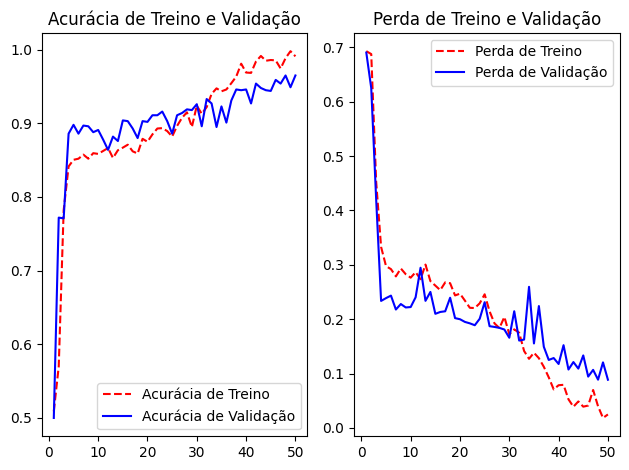

In [18]:
plota_resultado(history)

In [19]:
teste_modelo = keras.models.load_model("convnet_from_scratch.keras")
teste_perda, teste_acuracia = teste_modelo.evaluate(teste_dados)
print(f"Teste perda: {teste_perda:.3f}")
print(f"Teste acurácia: {teste_acuracia:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9770 - loss: 0.0606
Teste perda: 0.061
Teste acurácia: 0.977


In [20]:
import keras
from keras import layers
import tensorflow as tf

# 1. Agrupa as camadas em um Sequential
camada_aumento_dados = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02),
])


# 2. Aplica diretamente sobre o lote de imagens
def aumento_dados(imagens, alvo):
    return camada_aumento_dados(imagens, training=True), alvo


# 3. Pipeline tf.data
aumento_dados_treinamento = treinamento_dados.map(
    aumento_dados, num_parallel_calls=tf.data.AUTOTUNE
)
aumento_dados_treinamento = aumento_dados_treinamento.prefetch(
    tf.data.AUTOTUNE
)

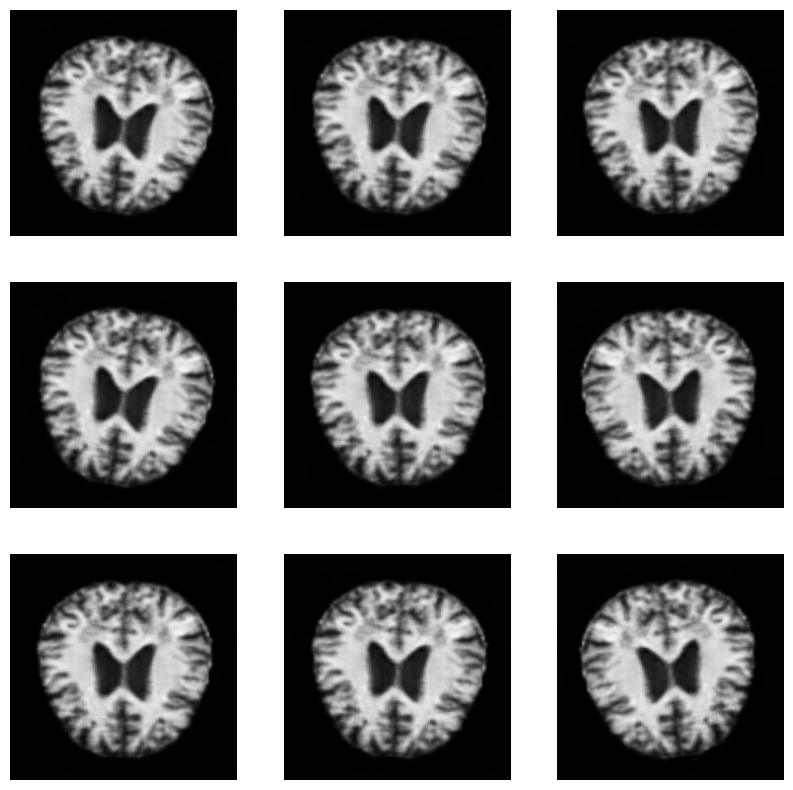

In [21]:
plt.figure(figsize=(10, 10))

for lote_imagens, _ in aumento_dados_treinamento.take(1):
  imagens = lote_imagens[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # Adiciona uma dimensão de lote à imagem única para que o modelo Sequential a processe corretamente
    imagem_aumentada, _ = aumento_dados(tf.expand_dims(imagens, 0), None)
    # Remove a dimensão de lote extra antes de converter para numpy para exibição
    imagem_aumentada = keras.ops.convert_to_numpy(imagem_aumentada[0])
    plt.imshow(imagem_aumentada.astype("uint8"))
    plt.axis("off")

In [22]:
entradas = keras.Input(shape=(224, 224,3))

x = layers.Rescaling(1.0 / 255)(entradas)
x = layers.Conv2D(filters = 32, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size= 2)(x)
x = layers.Conv2D(filters = 64, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size= 2)(x)
x = layers.Conv2D(filters = 128, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size= 2)(x)
x = layers.Conv2D(filters = 512, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size= 2)(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)
saidas = layers.Dense(1, activation="sigmoid")(x)

modelo = keras.Model(inputs=entradas, outputs=saidas)

modelo.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [23]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

history = modelo.fit(
    aumento_dados_treinamento,
    epochs = 100,
    validation_data = validacao_dados,
    callbacks = callbacks
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 232ms/step - accuracy: 0.4825 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - accuracy: 0.6065 - loss: 0.6375 - val_accuracy: 0.8560 - val_loss: 0.4522
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.8165 - loss: 0.4537 - val_accuracy: 0.8560 - val_loss: 0.4246
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.8080 - loss: 0.4483 - val_accuracy: 0.8560 - val_loss: 0.3926
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 190ms/step - accuracy: 0.8255 - loss: 0.4359 - val_accuracy: 0.8560 - val_loss: 0.3820
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.8275 - loss: 0.4281 - val_accuracy: 0.8560 - val_loss: 0.3877
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.8045 - loss: 0.4513 - val_accuracy: 0.8560 - val_loss: 0.3744
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.8200 - loss: 0.4275 - 

In [24]:
teste_modelo = keras.models.load_model("convnet_from_scratch.keras")
teste_perda, teste_acuracia = teste_modelo.evaluate(teste_dados)

print(f"Teste acurácia: {teste_acuracia:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9140 - loss: 0.1629
Teste acurácia: 0.914


Xception_41_imagenet


In [25]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

pre_processador = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(224, 224)
)

100%|██████████| 1.79k/1.79k [00:00<00:00, 8.29MB/s]


100%|██████████| 79.9M/79.9M [00:07<00:00, 11.4MB/s]


In [26]:
def obter_atributos_labels(conjunto_dados):
  todos_atributos = []
  todas_labels = []
  for imagens, labels in conjunto_dados:
    processa_imagens = pre_processador(imagens)
    atributos = conv_base.predict(processa_imagens, verbose=0)
    todos_atributos.append(atributos)
    todas_labels.append(labels)
  return np.concatenate(todos_atributos), np.concatenate(todas_labels)

atributos_treinamento, labels_treinamento = obter_atributos_labels(treinamento_dados)
atributos_validacao, labels_validacao = obter_atributos_labels(validacao_dados)
atributos_teste, labels_teste = obter_atributos_labels(teste_dados)


In [27]:
atributos_treinamento.shape

(2000, 7, 7, 2048)

In [28]:
entradas = keras.Input(shape=(7, 7, 2048))
x = layers.GlobalAveragePooling2D()(entradas)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
saidas = layers.Dense(1, activation="sigmoid")(x)

modelo = keras.Model(inputs=entradas, outputs=saidas)

modelo.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

history = modelo.fit(
    atributos_treinamento,
    labels_treinamento,
    epochs = 10,
    validation_data = (atributos_validacao, labels_validacao),
    callbacks = callbacks
)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.7960 - loss: 0.4202 - val_accuracy: 0.8620 - val_loss: 0.3164
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8465 - loss: 0.3299 - val_accuracy: 0.8680 - val_loss: 0.2938
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8560 - loss: 0.2916 - val_accuracy: 0.8910 - val_loss: 0.2511
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8800 - loss: 0.2586 - val_accuracy: 0.8630 - val_loss: 0.2788
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8870 - loss: 0.2551 - val_accuracy: 0.9010 - val_loss: 0.2308
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8885 - loss: 0.2355 - val_accuracy: 0.8990 - val_loss: 0.2249
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8835 - loss: 0.2491 - val_accuracy: 0.8930 - val_loss: 0.2213
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9085 - loss: 0.2062 - val_accuracy: 0.8910 - v

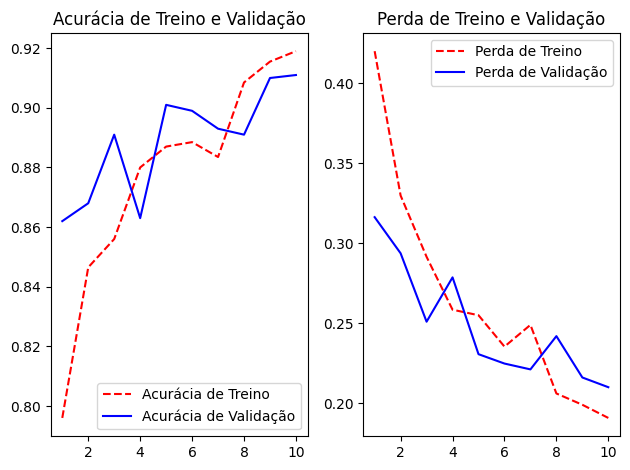

In [29]:
plota_resultado(history)

In [30]:
teste_modelo = keras.models.load_model("feature_extraction_with_data_augmentation.keras")
teste_perda, teste_acuracia = teste_modelo.evaluate(atributos_teste, labels_teste)
print(f"Teste acurácia: {teste_acuracia:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9070 - loss: 0.2016
Teste acurácia: 0.907


In [31]:
conv_base.trainable = True
len(conv_base.trainable_weights)

154

In [32]:
conv_base.trainable = False
len(conv_base.trainable_weights)

0

In [33]:
entradas = keras.Input(shape=(224, 224,3))

x = pre_processador(entradas)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128)(x)
x = layers.Dropout(0.2)(x)

saidas = layers.Dense(1, activation="sigmoid")(x)
modelo = keras.Model(inputs=entradas, outputs=saidas)

modelo.compile(
    loss = "binary_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [34]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

history = modelo.fit(
    aumento_dados_treinamento,
    epochs = 30,
    validation_data = validacao_dados,
    callbacks = callbacks
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 509ms/step - accuracy: 0.7570 - loss: 0.5306 - val_accuracy: 0.8740 - val_loss: 0.3142
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 289ms/step - accuracy: 0.8345 - loss: 0.3496 - val_accuracy: 0.8620 - val_loss: 0.2915
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 288ms/step - accuracy: 0.8520 - loss: 0.3108 - val_accuracy: 0.8820 - val_loss: 0.2561
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 276ms/step - accuracy: 0.8495 - loss: 0.3187 - val_accuracy: 0.8790 - val_loss: 0.2648
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 278ms/step - accuracy: 0.8765 - loss: 0.2802 - val_accuracy: 0.8540 - val_loss: 0.3031
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 279ms/step - accuracy: 0.8690 - loss: 0.2832 - val_accuracy: 0.8780 - val_loss: 0.2634
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 293ms/step - accuracy: 0.8840 - loss: 0.2655 - val_accuracy: 0.9010 - val_loss: 0.2332
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 280ms/step - accuracy: 0.8830 - loss: 0.2446 - val_accu

In [35]:
teste_modelo = keras.models.load_model("feature_extraction_with_data_augmentation.keras")
teste_perda, teste_acuracia = teste_modelo.evaluate(atributos_teste, labels_teste)
print(f"Teste acurácia: {teste_acuracia:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9070 - loss: 0.2016
Teste acurácia: 0.907


In [36]:
conv_base.trainable = True
for camada in conv_base.layers[:-10]: # Congela as camadas iniciais e libera só o topo
  camada.trainable = False

In [37]:
modelo.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"]
)

# 3. Callbacks com nome de arquivo exclusivo e ajuste dinâmico de LR
callbacks_xception_ft = [
    keras.callbacks.ModelCheckpoint(
        filepath="xception_alzheimer_finetuning.keras", # Nome único para não sobrescrever
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

# Treinamento de Fine-Tuning
history_xception_ft = modelo.fit(
    aumento_dados_treinamento,
    epochs=30,
    validation_data=validacao_dados,
    callbacks=callbacks_xception_ft
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 536ms/step - accuracy: 0.8585 - loss: 0.3605 - val_accuracy: 0.8410 - val_loss: 0.5501 - learning_rate: 1.0000e-05
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 304ms/step - accuracy: 0.8785 - loss: 0.2836 - val_accuracy: 0.8810 - val_loss: 0.3846 - learning_rate: 1.0000e-05
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 300ms/step - accuracy: 0.8970 - loss: 0.2396 - val_accuracy: 0.8960 - val_loss: 0.3132 - learning_rate: 1.0000e-05
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 287ms/step - accuracy: 0.9100 - loss: 0.2157 - val_accuracy: 0.9000 - val_loss: 0.2695 - learning_rate: 1.0000e-05
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - accuracy: 0.9230 - loss: 0.1941 - val_accuracy: 0.9080 - val_loss: 0.2448 - learning_rate: 1.0000e-05
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 315ms/step - accuracy: 0.9235 - loss: 0.1907 - val_accuracy: 0.9120 - val_loss: 0.2250 - learning_rate: 1.0000e-05
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 291ms/step - acc

In [38]:
# Carrega o modelo de Fine-Tuning
modelo_xception_teste = keras.models.load_model(
    "xception_alzheimer_finetuning.keras"
)

# Avalia diretamente usando teste_dados sem o map extra
teste_perda, teste_acuracia = modelo_xception_teste.evaluate(teste_dados)

print(f"\n==========================================")
print(f" Acurácia de Teste Xception (Fine-Tuning): {teste_acuracia:.4f}")
print(f"==========================================")

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 318 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 238ms/step - accuracy: 0.9490 - loss: 0.1694

 Acurácia de Teste Xception (Fine-Tuning): 0.9490


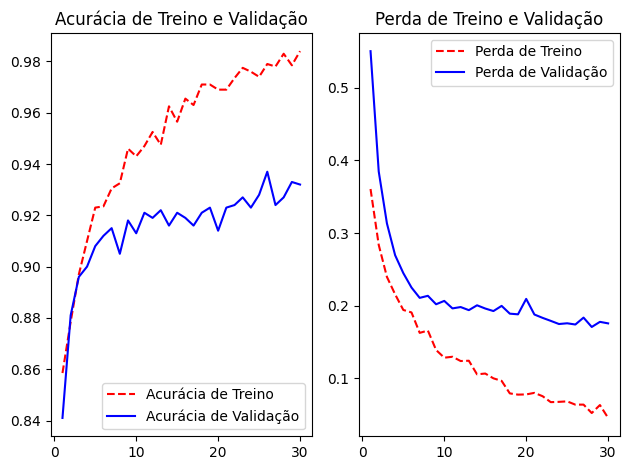

In [39]:
plota_resultado(history_xception_ft)

VGG16

In [40]:
from keras.applications import VGG16

# 1. Carregar a base da VGG16 pré-treinada no ImageNet
conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3) # Caso decida mudar para 224x224, ajuste aqui também
)

# Inicialmente congela a base para não destruir os pesos
conv_base.trainable = False

# 2. Construção do Modelo usando a VGG16
entradas = keras.Input(shape=(224, 224, 3))

# Normalização de pixels padrão para redes da família VGG
x = keras.applications.vgg16.preprocess_input(entradas)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x) # Ativação relu adicionada
x = layers.Dropout(0.3)(x)

saidas = layers.Dense(1, activation="sigmoid")(x)
modelo = keras.Model(inputs=entradas, outputs=saidas)

# 3. Compilação Inicial (Estágio 1 - Base Congelada)
modelo.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="vgg16_alzheimer_congelado.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

print("Treinando modelo base com VGG16 congelada...")
history = modelo.fit(
    aumento_dados_treinamento,
    epochs=20,
    validation_data=validacao_dados,
    callbacks=callbacks
)

# 4. Estágio 2: Fine-Tuning da VGG16 (Descongelando o último bloco de convoluções)
conv_base.trainable = True

# Congela todas as camadas com exceção do último bloco (block5)
for camada in conv_base.layers:
    if not camada.name.startswith("block5"):
        camada.trainable = False

# Recompila com Learning Rate baixo para o ajuste fino
modelo.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"]
)

callbacks_finetuning = [
    keras.callbacks.ModelCheckpoint(
        filepath="vgg16_alzheimer_finetuning.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

print("Iniciando Fine-Tuning das últimas camadas da VGG16...")
history = modelo.fit(
    aumento_dados_treinamento,
    epochs=30,
    validation_data=validacao_dados,
    callbacks=callbacks_finetuning
)

# 5. Avaliação do Modelo VGG16 Final no Conjunto de Teste
modelo_vgg16 = keras.models.load_model("vgg16_alzheimer_finetuning.keras")
test_loss, test_acc = modelo_vgg16.evaluate(teste_dados)

print(f"\n==========================================")
print(f" Acurácia de Teste com VGG16: {test_acc:.4f}")
print(f"==========================================")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Treinando modelo base com VGG16 congelada...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 560ms/step - accuracy: 0.7450 - loss: 0.7118 - val_accuracy: 0.8320 - val_loss: 0.3479
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 311ms/step - accuracy: 0.8380 - loss: 0.3715 - val_accuracy: 0.7750 - val_loss: 0.4333
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 320ms/step - accuracy: 0.8565 - loss: 0.3189 - val_accuracy: 0.8860 - val_loss: 0.2617
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.8795 - loss: 0.2678 - val_accuracy: 0.8800 - val_loss: 0.2708
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 314ms/step - accuracy: 0.8875 - loss: 0.2488 - val_accuracy: 0.8800 - val_loss: 0.2826
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 373ms/step - accuracy: 0.9015 - loss: 0.2371 - val_accuracy: 0.8990 - val_loss: 0.2319
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.8990 - loss: 0.2297 - val_accuracy: 0.8390 - val_loss: 0.3211
E

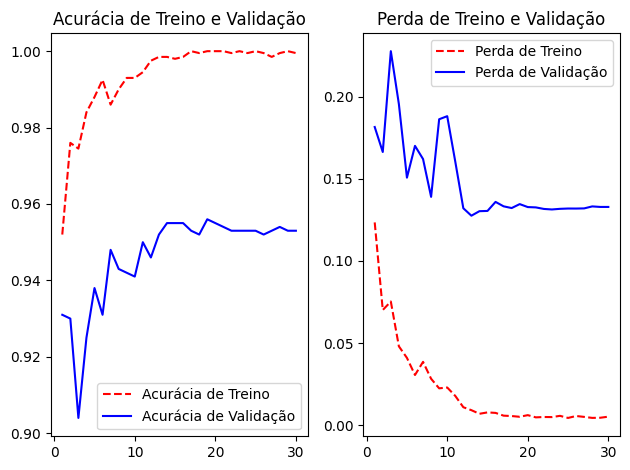

In [41]:
plota_resultado(history)